In [ ]:
from scipy.stats import entropy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as colors

In [2]:
jades_data = pd.read_csv("data/jades_dr5_photometric_catalog_subset.csv").drop("Unnamed: 0", axis="columns")

In [3]:
jades_data

,F090W_KRON,F115W_KRON,F150W_KRON,F182M_KRON,F200W_KRON,F277W_KRON,F335M_KRON,F356W_KRON,F410M_KRON,F435W_KRON,...,F814W_KRON,F850LP_KRON,F125W_KRON,F140W_KRON,F160W_KRON,Q,R_KRON,unscaled_F444W_KRON,ID,photoz
0,0.386780,0.300087,0.633389,1.255446,0.623497,0.876420,0.909183,0.886891,1.136959,0.299658,...,0.728978,0.487159,0.888711,-0.537893,0.693334,0.390726,0.745056,116.064542,490,2.80
1,1.760779,2.398820,1.858198,1.308508,1.686628,1.652174,1.775756,1.824354,0.883753,1.589711,...,1.974697,2.307263,2.268095,0.739194,1.037109,0.915636,0.326000,25.601965,519,0.76
2,-0.869462,0.835223,0.112352,1.001784,0.545806,1.268684,1.460337,1.533824,0.732482,-0.230372,...,0.287732,0.086536,-0.079786,1.770051,1.758321,0.954687,0.509296,30.149901,522,3.49
3,1.173474,0.947350,1.528584,1.542125,1.162309,1.234815,1.141565,1.110963,1.376555,1.168281,...,0.547270,0.725842,1.058812,0.827280,2.331888,0.544861,0.420613,89.744492,549,2.42
4,1.688582,1.449304,1.279279,2.667931,1.834312,1.253783,1.194935,1.174235,1.060439,0.431678,...,1.587199,4.443156,2.505961,1.790643,4.172483,0.860860,0.421539,28.120277,550,0.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89725,-0.090871,0.080197,0.138278,0.184751,0.043777,0.056973,0.094905,0.109284,0.557477,-0.447143,...,-0.025884,0.722157,0.044524,0.266411,0.031988,0.743172,0.244562,26.270901,3301718,8.61
89726,0.454743,0.371896,-0.101835,-0.975059,0.115758,0.154993,0.673163,0.116752,0.328982,-0.699361,...,0.156044,-0.727166,0.048787,1.411943,0.003833,0.560676,0.395464,41.189591,3301754,4.99
89727,-0.695332,-0.328651,-0.470085,-0.029591,0.133646,0.299675,-0.168792,-0.478896,-0.248164,-0.014939,...,0.065822,-0.073610,-0.091850,0.616456,0.829263,0.896412,0.422729,33.786540,3301987,4.22
89728,0.477811,0.263739,-0.168404,0.547131,0.541751,-0.017597,-0.128883,0.163685,0.952204,1.251010,...,-0.195149,0.323955,0.737724,-0.032473,0.553756,0.730629,0.267007,20.080720,3302027,17.30


In [67]:
F277W_KRON = jades_data["F277W_KRON"].values
F444W_KRON = jades_data["unscaled_F444W_KRON"].values

# Testing for outliers

## Possible methods to determine outliers:

1) Outliers are points greater than *x* sigma away from the median.

    a) Calculate the median of the distribution:
    
    `median = np.median(dist)`

    b) Calculate the standard deviation of the distribution centered at the median:
    
    `stddev = np.std(dist, mean=median)`

    c) Choose a value of sigma (e.g. `7`) outside of which to consider each value an outlier: 

    `upper_outliers =  dist > upper_bound`

    `lower_outliers =  dist < lower_bound`

2) k-Nearest Neighbors approach:

    a) Use https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html#sklearn.neighbors.LocalOutlierFactor.

If the distribution is multimodal, a Gaussian around the median is a bad representation of the data, so the sigma approach will remove points asymmetrically at the extremes of the distribution.

## Possible ways to treat outliers once identified:

If outliers are identified via the sigma approach:

1) Assign all values above the upper bound to the upper bound's value, and all values below the lower bound to the lower bound's value:

`dist_modified = np.copy(dist)`

`dist_modified[upper_outliers] = upper_bound`

`dist_modified[lower_outliers] = lower_bound`

2) Mask out all values above the upper bound and below the lower bound:

`dist_modified = np.copy(dist)`

`dist_modified = dist_modified[~upper_outliers & ~lower_outliers]`

In [ ]:
# # Source - https://stackoverflow.com/a/29222992
# # Posted by sergeyf, modified by community. See post 'Timeline' for change history
# # Retrieved 2026-06-23, License - CC BY-SA 3.0

# def doubleMADsfromMedian(y,thresh=5):

#     # warning: this function does not check for NAs
#     # nor does it address issues when 
#     # more than 50% of your data have identical values

#     m = np.median(y)
#     abs_dev = np.abs(y - m)
#     left_mad = np.median(abs_dev[y <= m])
#     right_mad = np.median(abs_dev[y >= m])
#     y_mad = left_mad * np.ones(len(y))
#     y_mad[y > m] = right_mad
#     modified_z_score = 0.6745 * abs_dev / y_mad
#     modified_z_score[y == m] = 0

#     return modified_z_score > thresh

# def handle_outliers(dist, method='sigma', treatment='reassign', sigma_value=7, thresh=5, n_neighbors=20):
#     """
#     Function to identify and handle outlier values in the distribution,
#     which would drastically change the scaling of the colorbar if not addressed.

#     Inputs
#     -------
#     dist: 1d float array
#         data to be represented by the colorbar.
#     method: str, default='sigma'
#         the method to use to identify outliers. options are 'sigma', 'double_mad', and 'knn'.
#     treatment: str, default='reassign'
#         how to treat the identified outliers. options are 'reassign' and 'mask_out'.
#     sigma_value: int, default 7
#         number of stddev to use when identifying outliers, if using the sigma method.
#     thresh: float, default 5
#     n_neighbors: int, default 20
#         number of nearest neighbors to consider, if using the knn method.
    
#     Outputs
#     -------
#     modified_dist: 1d float array
#         data to be represented by the colorbar, treated for outliers according to the specifications.
#     """

#     # choose the method to determine outliers

#     if method == 'sigma':
        
#         median = np.median(dist)
#         # center the gaussian at the median of the distribution
#         stddev = np.std(dist, mean=median)

#         lower_bound = median - sigma_value * stddev
#         upper_bound = median + sigma_value * stddev

#         # choose the method to treat outliers

#         if treatment == 'reassign':

#             # make a deep copy
#             dist_modified = np.copy(dist)
#             dist_modified[upper_outliers] = upper_bound
#             dist_modified[lower_outliers] = lower_bound

#         elif treatment == 'mask_out':

#             dist_modified = dist[~upper_outliers & ~lower_outliers]

#     elif method == 'double_mad':

#         outlier_mask = doubleMADsfromMedian(dist, thresh=5)

#         # choose the method to treat outliers

#         if treatment == 'reassign':

#             # make a deep copy
#             dist_modified = np.copy(dist)

#             upper_vals = dist > np.median()
#             dist_modified[outlier_mask] = upper_bound
#             dist_modified[lower_outliers] = lower_bound

#         elif treatment == 'mask_out':

#             dist_modified = dist[~upper_outliers & ~lower_outliers]

#     elif method == 'knn':

#         lof = LocalOutlierFactor(n_neighbors=n_neighbors)
#         outliers = lof.fit_predict(dist)
        

#     return dist_modified
    

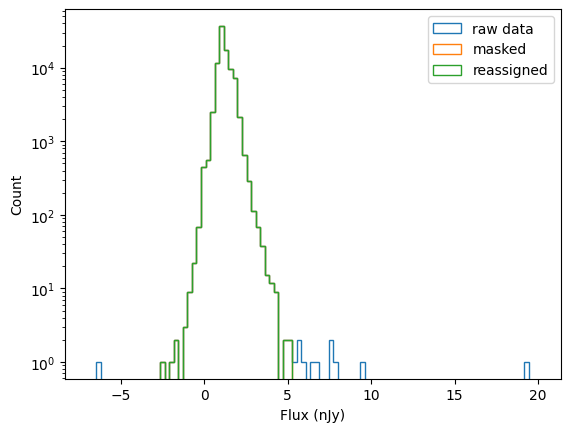

In [14]:
from outliers import handle_outliers

# test this function
F277W_KRON_modified = handle_outliers(F277W_KRON, sigma_value=10, treatment='mask_out')

plt.hist(F277W_KRON, bins=np.linspace(-7,20,100), label='raw data', histtype='step')
plt.hist(F277W_KRON_modified, bins=np.linspace(-7,20,100), label='masked', histtype='step')
plt.hist(F277W_KRON_modified, bins=np.linspace(-7,20,100), label='reassigned', histtype='step')
plt.yscale('log')
plt.xlabel('Flux (nJy)')
plt.ylabel('Count')
plt.legend()
plt.show()

# Testing for models

Models that only work with positive data: Log (base 10 or e)

Models that work for all data: Asinh, Linear, SymmetricalLog (base 10 or e)

Since SymmetricalLog will work the same as Log on data > 0, we could be tempted to only use SymmetricalLog, but Log should still be an option because it doesn't require choosing a linear interval around zero.

Also: it seems like we should aim for our tool to return a norm from matplotlib.colors.

In [26]:
# these functions return a function that can be operated on data

def no_norm_operator(data):
    return colors.NoNorm(vmin=np.min(data), vmax=np.max(data))

def asinh_norm_operator(data, linear_width=1):
    return colors.AsinhNorm(vmin=np.min(data), vmax=np.max(data), linear_width=linear_width)

def log_norm_operator(data):
    return colors.LogNorm(vmin=np.min(data), vmax=np.max(data))

def symlog_norm_operator(data, linthresh=0.1):
    return colors.SymLogNorm(vmin=np.min(data), vmax=np.max(data), linthresh=linthresh)

In [142]:
def get_scatterscale(data):
    """Optimal scaler

    Return the norm function corresponding to the visually-optimal data scaling. 
    Options are no normalization, Asinh, SymLog, and Log.

    Args:
        data (array): numpy vector. 1D data that the scaling is calculated for.

    Returns:
        matplotlib.colors.Norm: data normalization function
    """

    # These functions return a matplotlib.colors norm function that can be operated on data or directly
    # used as the norm for a colorbar.
    def no_norm_operator(data):
        return colors.NoNorm(vmin=np.nanmin(data), vmax=np.nanmax(data))
    def asinh_norm_operator(data, linear_width=1):
        return colors.AsinhNorm(vmin=np.nanmin(data), vmax=np.nanmax(data), linear_width=linear_width)
    def log_norm_operator(data):
        return colors.LogNorm(vmin=np.nanmin(data), vmax=np.nanmax(data))
    def symlog_norm_operator(data, linthresh=0.1):
        return colors.SymLogNorm(vmin=np.nanmin(data), vmax=np.nanmax(data), linthresh=linthresh)
    
    all_scalings = [no_norm_operator, asinh_norm_operator, symlog_norm_operator, log_norm_operator]
    all_scaling_names = ["No normalization", "Asinh (linear_width=1)", "SymLog (linthresh=0.1)", "Log"]
    if not np.all(data > 0):
        all_scalings = all_scalings[:-1] # get rid of log scaling option for data that has values <= 0

    entropies = []
    for i, get_scaling_operator in enumerate(all_scalings):
        scaling_operator = get_scaling_operator(data)
        scaled_data = scaling_operator(data)

        if all_scaling_names[i] == "No normalization":
            # scale to a range of 0 to 1 so that entropy can be calculated (otherwise fails for negative values)
            scaled_data_min = np.min(scaled_data)
            scaled_data_max = np.max(scaled_data)
            reranged_scaled_data = (scaled_data - scaled_data_min) / (scaled_data_max - scaled_data_min)
            entropies.append(entropy(reranged_scaled_data))
        else:
            entropies.append(entropy(scaled_data))

    # the distribution with max entropy has its values spread out the most evenly over the range
    loc_max_entropy = np.argmax(entropies)
    get_best_scaling_operator = all_scalings[loc_max_entropy]
    print(f"Best scaling: {all_scaling_names[loc_max_entropy]}")
    return get_best_scaling_operator(data)

Best scaling: SymLog (linthresh=0.1)


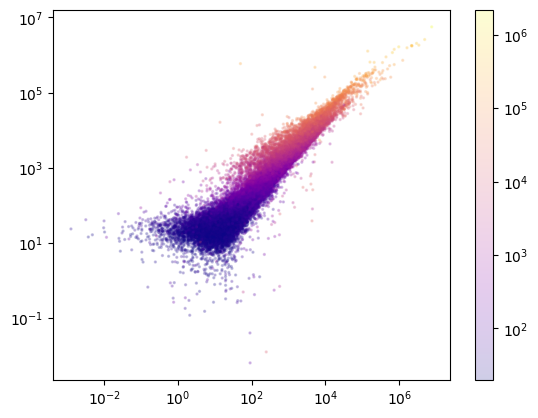

In [110]:
F444W_KRON_norm = get_scatterscale(F444W_KRON)
plt.scatter(jades_data["F090W_KRON"].values * F444W_KRON, jades_data["F200W_KRON"].values * F444W_KRON, c=F444W_KRON, norm=F444W_KRON_norm, cmap="plasma", alpha=0.2, s=2)
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.show()

Best scaling: No normalization


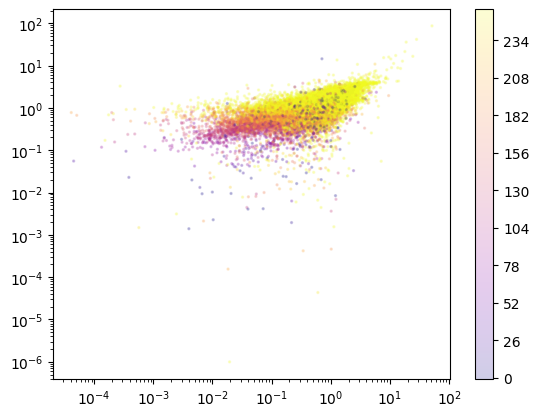

In [100]:
F277W_KRON_norm = get_scatterscale(F277W_KRON)
plt.scatter(jades_data["F090W_KRON"], jades_data["F200W_KRON"], c=F277W_KRON, norm=F277W_KRON_norm, cmap="plasma", alpha=0.2, s=2)
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.show()

In [ ]:
# from choose_scaler import get_scatterscale as scatterscale_test

Best scaling: No normalization


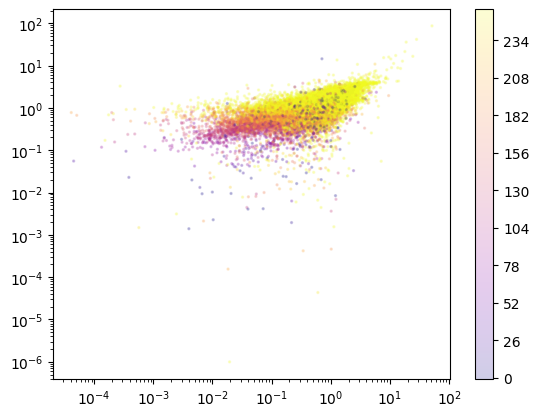

In [105]:
F277W_KRON_norm = scatterscale_test(F277W_KRON)
plt.scatter(jades_data["F090W_KRON"], jades_data["F200W_KRON"], c=F277W_KRON, norm=F277W_KRON_norm, cmap="plasma", alpha=0.2, s=2)
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.show()

In [107]:
type(F277W_KRON_norm)

matplotlib.colors.NoNorm

## Converting the colors back to fluxes and testing their scalings

In [183]:
example_jades_data = pd.DataFrame()
example_jades_data["ID"] = jades_data["ID"]
example_jades_data["F090W_KRON"] = jades_data["F090W_KRON"] * F444W_KRON
example_jades_data["F182M_KRON"] = jades_data["F182M_KRON"] * F444W_KRON
example_jades_data["F200W_KRON"] = jades_data["F200W_KRON"] * F444W_KRON
example_jades_data["F444W_KRON"] = F444W_KRON
example_jades_data["photoz"] = jades_data["photoz"]

In [184]:
example_jades_data

,ID,F090W_KRON,F182M_KRON,F200W_KRON,F444W_KRON,photoz
0,490,44.891501,145.712765,72.365925,116.064542,2.80
1,519,45.079392,33.500378,43.180997,25.601965,0.76
2,522,-26.214179,30.203677,16.456006,30.149901,3.49
3,549,105.312790,138.397255,104.310861,89.744492,2.42
4,550,47.483395,75.022954,51.581375,28.120277,0.72
...,...,...,...,...,...,...
89725,3301718,-2.387266,4.853579,1.150072,26.270901,8.61
89726,3301754,18.730689,-40.162270,4.768035,41.189591,4.99
89727,3301987,-23.492848,-0.999764,4.515437,33.786540,4.22
89728,3302027,9.594798,10.986778,10.878755,20.080720,17.30


In [185]:
example_jades_data.to_csv("jades_dr5_demo_data.csv", index=False)

[np.float64(10.14288369663901), np.float64(11.392975568162788), np.float64(11.393360760678627)]
Best scaling: SymLog (linthresh=0.1)


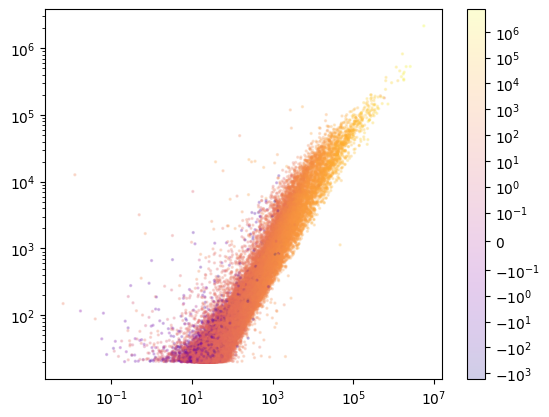

In [135]:
F090W_KRON_norm = scatterscale_test(example_jades_data["F090W_KRON"].values)
plt.scatter(example_jades_data["F200W_KRON"], example_jades_data["F444W_KRON"], c=example_jades_data["F090W_KRON"].values, norm=F090W_KRON_norm, cmap="plasma", alpha=0.2, s=2)
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.show()

In [159]:
import numpy as np

def handle_outliers(data, sigma_value=10, treatment='reassign', verbose=False):
    """
    Function to identify and handle outlier values in the distribution, which would drastically change the scaling of the colorbar if not addressed.

    Args
        data (1d float array): data to be represented by the colorbar.
        sigma_value (int, default 10): number of stddev to use when identifying outliers, if using the sigma method.
        treatment (str, default='reassign'): how to treat the identified outliers; options are 'reassign' and 'mask_out'.
        verbose (bool, default=False): whether to display the number of outliers identified.
    
    Returns
        data_modified (1d float array): data to be represented by the colorbar, treated for outliers according to the specifications.
    """
        
    median = np.median(data)
    # center the gaussian at the median of the distribution
    stddev = np.std(data, mean=median)

    lower_bound = median - sigma_value * stddev
    upper_bound = median + sigma_value * stddev

    upper_outliers =  data > upper_bound
    lower_outliers =  data < lower_bound

    # make a deep copy
    data_modified = np.copy(data)

    # choose the method to treat outliers

    if treatment == 'reassign':

        data_modified[upper_outliers] = upper_bound
        data_modified[lower_outliers] = lower_bound

    elif treatment == 'mask_out':

        data_modified[upper_outliers & lower_outliers] = np.nan

    if verbose == True:
        print(f'{np.sum(upper_outliers)} upper outliers found.')
        print(f'{np.sum(lower_outliers)} lower outliers found.')

    return data_modified

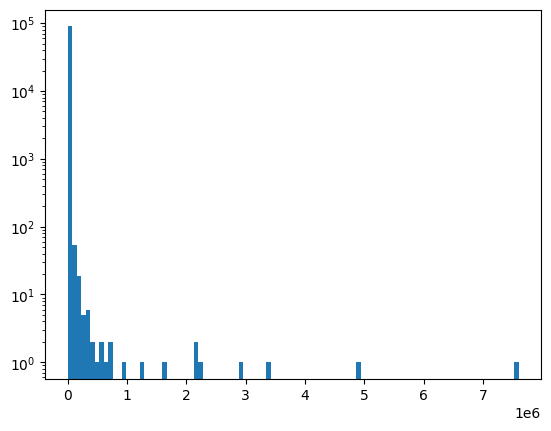

In [163]:
plt.hist(example_jades_data["F090W_KRON"].values, bins=100)
plt.yscale("log")
plt.show()

In [186]:
np.__version__

'2.2.5'

197 upper outliers found.
0 lower outliers found.
Best scaling: SymLog (linthresh=0.1)


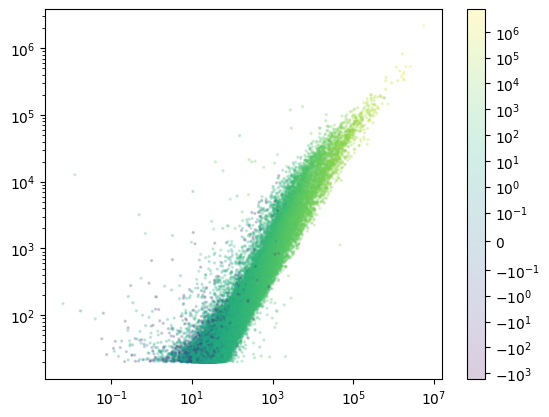

In [165]:
# same but handle outliers
F090W_outliered = handle_outliers(example_jades_data["F090W_KRON"].values, sigma_value=1, treatment="mask_out", verbose=True)

F090W_KRON_norm = get_scatterscale(F090W_outliered)
plt.scatter(example_jades_data["F200W_KRON"], example_jades_data["F444W_KRON"], c=F090W_outliered, norm=F090W_KRON_norm, cmap="viridis", alpha=0.2, s=2)
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.show()

[np.float64(10.14288369663901), np.float64(11.392975568162788), np.float64(11.393360760678627)]
Best scaling: SymLog (linthresh=0.1)


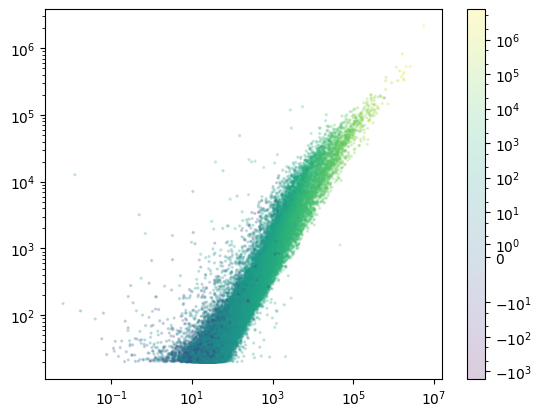

In [164]:
F090W_KRON_norm = scatterscale_test(example_jades_data["F090W_KRON"].values)
plt.scatter(example_jades_data["F200W_KRON"], example_jades_data["F444W_KRON"], c=example_jades_data["F090W_KRON"].values, 
norm=colors.AsinhNorm(vmin=min(example_jades_data["F090W_KRON"]), vmax=max(example_jades_data["F090W_KRON"])), cmap="viridis", alpha=0.2, s=2)
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.show()

Best scaling: SymLog (linthresh=0.1)


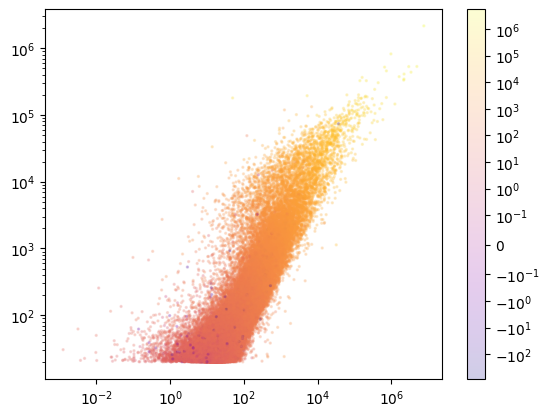

In [ ]:
F200W_KRON_norm = scatterscale_test(example_jades_data["F200W_KRON"].values)
plt.scatter(example_jades_data["F090W_KRON"], example_jades_data["F444W_KRON"], c=example_jades_data["F200W_KRON"].values, norm=F200W_KRON_norm, cmap="plasma", alpha=0.2, s=2)
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.show()

Best scaling: SymLog (linthresh=0.1)


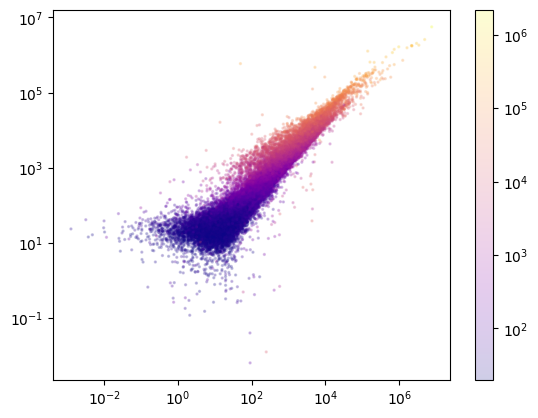

In [120]:
F444W_KRON_norm = scatterscale_test(example_jades_data["F444W_KRON"].values)
plt.scatter(example_jades_data["F090W_KRON"], example_jades_data["F200W_KRON"], c=example_jades_data["F444W_KRON"].values, norm=F444W_KRON_norm, cmap="plasma", alpha=0.2, s=2)
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.show()

In [179]:
get_scatterscale(jades_data["F182M_KRON"].values * F444W_KRON)

Best scaling: No normalization
